# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

## Inicialização

In [1]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats




## Carregue os dados

In [2]:

# Carregando os datasets
calls    = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans    = pd.read_csv('/datasets/megaline_plans.csv')
users    = pd.read_csv('/datasets/megaline_users.csv')




## Prepare os dados

## Planos

In [3]:


# Imprima informações gerais/resumo sobre o DataFrame dos planos
print("=== INFORMAÇÕES GERAIS ===")
print(plans.info())

print("\n=== PRIMEIRAS LINHAS ===")
print(plans.head())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(plans.describe())





=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None

=== PRIMEIRAS LINHAS ===
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_mi

In [4]:


# Imprima uma amostra de dados dos planos
print(plans.sample(frac=1).reset_index(drop=True))





   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


Observações sobre a tabela users:
- reg_date e churn_date estão como object. Isso precisa mudar para datetime antes de qualquer cálculo temporal — especialmente para filtrar só os meses em que o usuário estava ativo no serviço.

Observações sobre a tabela calls:
- O enunciado diz que a Megaline arredonda cada chamada individual para cima — ou seja, uma chamada de 0.5 minuto vira 1 minuto cobrado. Então duration precisa ser arredondada com ceil antes de qualquer agregação.
- call_date está como object e precisa virar datetime.

Observações sobre a tabela messages:
- message_date está como object

Observações sobre a tabela internet:
- session_date está como object e precisa de conversão para datetime, igual às outras.




## Corrija os dados

In [5]:
# ── USERS ──────────────────────────────────────────────────────────────────

# reg_date e churn_date vieram como texto (object); convertendo para datetime
# para poder filtrar por mês e fazer cálculos de período depois
users['reg_date']   = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])

# ── CALLS ──────────────────────────────────────────────────────────────────

# Mesma conversão de data
calls['call_date'] = pd.to_datetime(calls['call_date'])

# A Megaline arredonda cada chamada individualmente para cima:
# uma chamada de 0.5 min vira 1 min cobrado
# np.ceil faz esse arredondamento; convertemos para int porque
# minuto fracionado não existe mais depois disso
calls['duration'] = np.ceil(calls['duration']).astype(int)

# ── MESSAGES ───────────────────────────────────────────────────────────────

# Só a data precisava de correção nessa tabela
messages['message_date'] = pd.to_datetime(messages['message_date'])

# ── INTERNET ───────────────────────────────────────────────────────────────

# Mesma conversão de data
# O arredondamento de MB para GB não é feito aqui — o enunciado diz que
# ele acontece sobre o total mensal, não por sessão individual;
# isso será tratado na etapa de cálculo de receita
internet['session_date'] = pd.to_datetime(internet['session_date'])

# ── VERIFICAÇÃO ────────────────────────────────────────────────────────────

# Imprime os tipos de cada tabela para confirmar que as conversões funcionaram
for name, df in [('users', users), ('calls', calls),
                 ('messages', messages), ('internet', internet)]:
    print(f"--- {name} ---")
    print(df.dtypes, "\n")

--- users ---
user_id                int64
first_name            object
last_name             object
age                    int64
city                  object
reg_date      datetime64[ns]
plan                  object
churn_date    datetime64[ns]
dtype: object 

--- calls ---
id                   object
user_id               int64
call_date    datetime64[ns]
duration              int64
dtype: object 

--- messages ---
id                      object
user_id                  int64
message_date    datetime64[ns]
dtype: object 

--- internet ---
id                      object
user_id                  int64
session_date    datetime64[ns]
mb_used                float64
dtype: object 



## Enriqueça os dados

In [6]:
# ── EXTRAINDO O MÊS DE CADA TABELA DE EVENTOS ──────────────────────────────

# Vamos precisar agrupar tudo por usuário e mês; extrair o mês agora
# evita repetir essa operação em cada agregação depois
calls['month']    = calls['call_date'].dt.month
messages['month'] = messages['message_date'].dt.month
internet['month'] = internet['session_date'].dt.month


# ── AGREGAÇÕES MENSAIS POR USUÁRIO ─────────────────────────────────────────

# Total de minutos e número de chamadas por usuário por mês
calls_monthly = (
    calls
    .groupby(['user_id', 'month'])
    .agg(calls_count=('id', 'count'),
         minutes_used=('duration', 'sum'))
    .reset_index()
)

# Total de mensagens por usuário por mês
messages_monthly = (
    messages
    .groupby(['user_id', 'month'])
    .agg(messages_count=('id', 'count'))
    .reset_index()
)

# Total de MB por usuário por mês — arredondado para GB após a soma,
# conforme a regra da Megaline (arredondamento é sobre o total mensal)
internet_monthly = (
    internet
    .groupby(['user_id', 'month'])
    .agg(mb_used=('mb_used', 'sum'))
    .reset_index()
)
internet_monthly['gb_used'] = np.ceil(internet_monthly['mb_used'] / 1024).astype(int)


# ── MONTANDO A TABELA ANALÍTICA PRINCIPAL ──────────────────────────────────

# Partimos dos usuários e vamos juntando os dados de cada serviço
# Usamos left join para manter todos os usuários, mesmo os que não
# usaram determinado serviço em algum mês (esses vão virar 0)
df = users[['user_id', 'plan']].drop_duplicates()

df = (
    df
    .merge(calls_monthly,    on='user_id', how='left')
    .merge(messages_monthly, on=['user_id', 'month'], how='left')
    .merge(internet_monthly, on=['user_id', 'month'], how='left')
)

# Preenchendo NaN com 0 — usuário que não ligou/mandou mensagem/usou
# internet em determinado mês simplesmente não consumiu nada
df[['calls_count', 'minutes_used',
    'messages_count', 'mb_used', 'gb_used']] = (
    df[['calls_count', 'minutes_used',
        'messages_count', 'mb_used', 'gb_used']].fillna(0)
)


# ── CALCULANDO A RECEITA MENSAL ─────────────────────────────────────────────

# Trazendo os parâmetros dos planos para o dataframe principal
df = df.merge(plans, left_on='plan', right_on='plan_name', how='left')

# Excedente de minutos, mensagens e GB (não pode ser negativo)
df['extra_minutes']  = (df['minutes_used']  - df['minutes_included']).clip(lower=0)
df['extra_messages'] = (df['messages_count'] - df['messages_included']).clip(lower=0)
df['extra_gb']       = (df['gb_used'] - df['mb_per_month_included'] / 1024).clip(lower=0)

# Receita = taxa mensal fixa + cobrança pelo excedente de cada serviço
df['revenue'] = (
    df['usd_monthly_pay']
    + df['extra_minutes']  * df['usd_per_minute']
    + df['extra_messages'] * df['usd_per_message']
    + df['extra_gb']       * df['usd_per_gb']
)

# Removendo colunas auxiliares dos planos que não serão mais necessárias
df = df.drop(columns=['plan_name', 'mb_per_month_included', 'minutes_included',
                       'messages_included', 'usd_monthly_pay', 'usd_per_minute',
                       'usd_per_message', 'usd_per_gb'])


# ── VERIFICAÇÃO ─────────────────────────────────────────────────────────────

print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nTipos:\n{df.dtypes}")
print(f"\nReceita média por plano:\n{df.groupby('plan')['revenue'].mean().round(2)}")

   user_id      plan  month  calls_count  minutes_used  messages_count  \
0     1000  ultimate   12.0         16.0         124.0            11.0   
1     1001      surf    8.0         27.0         182.0            30.0   
2     1001      surf    9.0         49.0         315.0            44.0   
3     1001      surf   10.0         65.0         393.0            53.0   
4     1001      surf   11.0         64.0         426.0            36.0   
5     1001      surf   12.0         56.0         412.0            44.0   
6     1002      surf   10.0         11.0          59.0            15.0   
7     1002      surf   11.0         55.0         386.0            32.0   
8     1002      surf   12.0         47.0         384.0            41.0   
9     1003      surf   12.0        149.0        1104.0            50.0   

    mb_used  gb_used  extra_minutes  extra_messages  extra_gb  revenue  
0   1901.47      2.0            0.0             0.0       0.0    70.00  
1   6919.15      7.0            0.0    

## Usuários

In [7]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários

# Informações gerais sobre a tabela de usuários
print("=== INFORMAÇÕES GERAIS ===")
print(users.info())

print("\n=== PRIMEIRAS LINHAS ===")
print(users.head())

print("\n=== VALORES AUSENTES ===")
print(users.isnull().sum())

print("\n=== DISTRIBUIÇÃO POR PLANO ===")
print(users['plan'].value_counts())

print("\n=== DISTRIBUIÇÃO POR CIDADE ===")
print(users['city'].value_counts().head(10))

print("\n=== ESTATÍSTICAS DE IDADE ===")
print(users['age'].describe())

=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None

=== PRIMEIRAS LINHAS ===
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vega

In [8]:
# Imprima uma amostra de dados dos usuários

print(users.sample(10, random_state=42))


     user_id first_name last_name  age  \
361     1361    Jacelyn   Hoffman   45   
73      1073      Grady  Crawford   30   
374     1374      Ching     Watts   55   
155     1155     Claude      Hahn   19   
104     1104    Thurman  Stephens   20   
394     1394  Alejandro    Carver   28   
377     1377     Vallie    Conway   18   
124     1124     Jenell   Navarro   48   
68      1068     Marcel   Jimenez   47   
450     1450      Errol   Marquez   67   

                                              city   reg_date      plan  \
361                      Birmingham-Hoover, AL MSA 2018-04-14      surf   
73          Chicago-Naperville-Elgin, IL-IN-WI MSA 2018-04-06      surf   
374         Louisville/Jefferson County, KY-IN MSA 2018-02-14      surf   
155  Miami-Fort Lauderdale-West Palm Beach, FL MSA 2018-02-21  ultimate   
104         Chicago-Naperville-Elgin, IL-IN-WI MSA 2018-12-23  ultimate   
394                               Stockton, CA MSA 2018-01-16      surf   
377         

- Os tipos estão corretos após as correções anteriores.
- Divisão entre planos: 339 no Surf contra 161 no Ultimate. Quase 70% dos clientes estão no plano mais barato. Se o Surf aparecer gerando mais receita total, boa parte disso vai ser por volume de usuários, não porque o plano em si é mais lucrativo. A comparação que interessa ao departamento comercial é receita média por usuário.
- NY-NJ aparece com 80 clientes, mais que o dobro de LA que vem logo atrás. 
- Idades entre 18 e 75 anos, mediana em 46.


### Corrija os dados

In [9]:
# A tabela users não requer correções adicionais.
# As únicas alterações necessárias (conversão de reg_date e churn_date
# para datetime) já foram feitas na etapa 1.5.
# Os nulos em churn_date são esperados e não devem ser alterados.

print("Tipos atuais:")
print(users.dtypes)
print("\nValores ausentes:")
print(users.isnull().sum())

Tipos atuais:
user_id                int64
first_name            object
last_name             object
age                    int64
city                  object
reg_date      datetime64[ns]
plan                  object
churn_date    datetime64[ns]
dtype: object

Valores ausentes:
user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64


### Enriqueça os dados

In [10]:
# Flag para identificar usuários da região NY-NJ
users['is_nynj'] = users['city'].str.contains('NY-NJ')

# Flag para usuários que cancelaram o serviço durante 2018
# Útil para separar análises entre clientes ativos e churned
users['churned'] = users['churn_date'].notna()


Dois campos novos, cada um com uma função clara:
- is_nynj evita ter que reescrever o filtro de string toda vez que precisar separar essa região.
- churned transforma a lógica de "tem ou não tem data de cancelamento" em algo mais legível no código. Não muda nenhum dado — só deixa a intenção mais explícita quando o campo for usado como filtro.



## Chamadas

In [11]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
print("=== INFORMAÇÕES GERAIS ===")
print(calls.info())

print("\n=== PRIMEIRAS LINHAS ===")
print(calls.head())

print("\n=== VALORES AUSENTES ===")
print(calls.isnull().sum())

print("\n=== ESTATÍSTICAS DA DURAÇÃO ===")
print(calls['duration'].describe())

print("\n=== CHAMADAS COM DURAÇÃO ZERO ===")
print(f"Quantidade: {(calls['duration'] == 0).sum()}")

print("\n=== CHAMADAS POR MÊS ===")
print(calls['month'].value_counts().sort_index())


=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
 4   month      137735 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 5.3+ MB
None

=== PRIMEIRAS LINHAS ===
         id  user_id  call_date  duration  month
0   1000_93     1000 2018-12-27         9     12
1  1000_145     1000 2018-12-27        14     12
2  1000_247     1000 2018-12-27        15     12
3  1000_309     1000 2018-12-28         6     12
4  1000_380     1000 2018-12-30         5     12

=== VALORES AUSENTES ===
id           0
user_id      0
call_date    0
duration     0
month        0
dtype: int64

=== ESTATÍSTICAS D

In [12]:
# Imprima uma amostra de dados das chamadas
print(calls.sample(10, random_state=42))


              id  user_id  call_date  duration  month
52288   1187_481     1187 2018-12-12         0     12
30634   1114_568     1114 2018-10-21         2     10
54228   1196_106     1196 2018-07-23         6      7
110372  1389_454     1389 2018-05-12        12      5
109600   1386_60     1386 2018-11-24         0     11
87094   1320_763     1320 2018-06-23         4      6
67527    1242_23     1242 2018-11-15        14     11
9557    1042_494     1042 2018-11-05         8     11
104970   1369_55     1369 2018-12-28         0     12
124419  1439_287     1439 2018-08-16         9      8


- 137.735 registros. Sem nulos, tipos corretos.
- A distribuição por mês é o que mais chama atenção: 172 chamadas em janeiro contra 30.614 em dezembro. À primeira vista parece erro, mas faz sentido quando se lembra que os usuários foram se cadastrando ao longo de 2018 — quem entrou em novembro só tem dados de novembro e dezembro. 
- As 26.834 chamadas com duração zero merecem atenção. São quase 20% dos registros — chamadas que não completaram ou caíram antes de qualquer segundo. 
- O campo id está como object no formato user_id_sequencial. Não tem utilidade analítica direta, só serve para garantir que não há registros duplicados.

### Corrija os dados

In [13]:
# As correções da tabela calls foram feitas na etapa 1.5.
# Aqui apenas confirmamos que os zeros em duration continuaram
# como zero após o np.ceil aplicado anteriormente.

print("Chamadas com duração zero após o arredondamento:")
print((calls['duration'] == 0).sum())

print("\nMenor valor de duration:")
print(calls['duration'].min())

print("\nTipos atuais:")
print(calls.dtypes)

Chamadas com duração zero após o arredondamento:
26834

Menor valor de duration:
0

Tipos atuais:
id                   object
user_id               int64
call_date    datetime64[ns]
duration              int64
month                 int64
dtype: object


### Enriqueça os dados

In [14]:
# month já foi extraído na etapa 1.6
# A única adição útil aqui é uma flag para chamadas que de fato completaram
# Vai facilitar filtros futuros caso a análise precise separar
# chamadas reais de tentativas sem conexão

calls['completed'] = calls['duration'] > 0


## Mensagens

In [15]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens

print("=== INFORMAÇÕES GERAIS ===")
print(messages.info())

print("\n=== PRIMEIRAS LINHAS ===")
print(messages.head())

print("\n=== VALORES AUSENTES ===")
print(messages.isnull().sum())

print("\n=== MENSAGENS POR MÊS ===")
print(messages['month'].value_counts().sort_index())

print("\n=== MENSAGENS POR USUÁRIO ===")
print(messages.groupby('user_id')['id'].count().describe())

=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 2.3+ MB
None

=== PRIMEIRAS LINHAS ===
         id  user_id message_date  month
0  1000_125     1000   2018-12-27     12
1  1000_160     1000   2018-12-31     12
2  1000_223     1000   2018-12-31     12
3  1000_251     1000   2018-12-27     12
4  1000_255     1000   2018-12-26     12

=== VALORES AUSENTES ===
id              0
user_id         0
message_date    0
month           0
dtype: int64

=== MENSAGENS POR MÊS ===
1        83
2       259
3       594
4      1333
5      2780
6      3833
7      52

In [16]:
# Imprima uma amostra dos dados das mensagens
print(messages.sample(10, random_state=42))


              id  user_id message_date  month
58331   1369_132     1369   2018-12-27     12
24196    1145_51     1145   2018-07-11      7
9284     1069_42     1069   2018-12-03     12
44214  1293_1181     1293   2018-10-06     10
57006    1362_72     1362   2018-05-25      5
65485    1421_70     1421   2018-12-21     12
10405   1076_916     1076   2018-11-23     11
36070    1237_91     1237   2018-09-02      9
31581    1196_64     1196   2018-06-27      6
15257   1101_314     1101   2018-12-16     12


- Sem nulos, sem tipo errado. As correções da etapa 1.5 resolveram tudo que precisava ser resolvido.
- A distribuição mensal segue o mesmo padrão de calls — 83 mensagens em janeiro, quase 19 mil em dezembro. 
- Só 402 dos 500 usuários aparecem nessa tabela. Os outros 98 não mandaram nenhuma mensagem no ano inteiro. 

### Corrija os dados

In [17]:
# As correções da tabela messages foram feitas na etapa 1.5.
# message_date já está como datetime e month já foi extraído.
# Não há zeros para verificar como em calls, nem nulos inesperados.

print("Tipos atuais:")
print(messages.dtypes)

print("\nValores ausentes:")
print(messages.isnull().sum())

Tipos atuais:
id                      object
user_id                  int64
message_date    datetime64[ns]
month                    int64
dtype: object

Valores ausentes:
id              0
user_id         0
message_date    0
month           0
dtype: int64


### Enriqueça os dados

In [18]:
# month já foi extraído na etapa 1.6 e é tudo que essa tabela precisa
# Não há duração, tamanho ou qualquer outra métrica por mensagem individual
# — cada linha já representa exatamente uma mensagem enviada

# Confirmando que month está presente e correto
print(messages[['user_id', 'message_date', 'month']].sample(5, random_state=42))
print(f"\nMeses presentes: {sorted(messages['month'].unique())}")

       user_id message_date  month
58331     1369   2018-12-27     12
24196     1145   2018-07-11      7
9284      1069   2018-12-03     12
44214     1293   2018-10-06     10
57006     1362   2018-05-25      5

Meses presentes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


## Internet

In [19]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
print("=== INFORMAÇÕES GERAIS ===")
print(internet.info())

print("\n=== PRIMEIRAS LINHAS ===")
print(internet.head())

print("\n=== VALORES AUSENTES ===")
print(internet.isnull().sum())

print("\n=== ESTATÍSTICAS DE USO DE DADOS ===")
print(internet['mb_used'].describe())

print("\n=== SESSÕES COM USO ZERO ===")
print(f"Quantidade: {(internet['mb_used'] == 0).sum()}")

print("\n=== SESSÕES POR MÊS ===")
print(internet['month'].value_counts().sort_index())

print("\n=== USO POR USUÁRIO (MB TOTAL NO ANO) ===")
print(internet.groupby('user_id')['mb_used'].sum().describe())


=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 4.0+ MB
None

=== PRIMEIRAS LINHAS ===
         id  user_id session_date  mb_used  month
0   1000_13     1000   2018-12-29    89.86     12
1  1000_204     1000   2018-12-31     0.00     12
2  1000_379     1000   2018-12-28   660.40     12
3  1000_413     1000   2018-12-26   270.99     12
4  1000_442     1000   2018-12-27   880.22     12

=== VALORES AUSENTES ===
id              0
user_id         0
session_date    0
mb_used       

In [20]:
#  Imprima uma amostra de dados para o tráfego da internet
print(internet.sample(10, random_state=42))


              id  user_id session_date  mb_used  month
102423  1490_238     1490   2018-10-15   373.01     10
12472   1060_181     1060   2018-09-14   875.38      9
91959    1426_53     1426   2018-12-29   627.48     12
42208   1187_385     1187   2018-09-20   132.80      9
64201   1294_122     1294   2018-10-29   397.70     10
51936    1233_16     1233   2018-10-23   241.69     10
97479     1460_2     1460   2018-06-16   783.37      6
35337    1160_41     1160   2018-09-02     0.00      9
69100    1322_13     1322   2018-11-27   620.49     11
21688   1099_443     1099   2018-07-03   714.42      7


- A amostra já mostra uma sessão com mb_used == 0 no registro 1160_41. São 13.747 assim no total, quase 13% dos registros. 
- 489 dos 500 usuários aparecem na tabela. Os 11 que faltam não registraram nenhuma sessão no ano — precisam entrar no dataframe consolidado com zero, não sumir.

### Corrija os dados

In [21]:
# As correções da tabela internet foram feitas na etapa 1.5.
# session_date já está como datetime e month já foi extraído.
# As sessões com mb_used == 0 são mantidas — somam zero e
# não afetam o cálculo do total mensal.

print("Tipos atuais:")
print(internet.dtypes)

print("\nValores ausentes:")
print(internet.isnull().sum())

print("\nMenor valor de mb_used:")
print(internet['mb_used'].min())

Tipos atuais:
id                      object
user_id                  int64
session_date    datetime64[ns]
mb_used                float64
month                    int64
dtype: object

Valores ausentes:
id              0
user_id         0
session_date    0
mb_used         0
month           0
dtype: int64

Menor valor de mb_used:
0.0


### Enriqueça os dados

In [22]:
# month já foi extraído na etapa 1.6
# A única adição que faz sentido é uma flag para sessões com uso real,
# equivalente ao completed em calls — facilita filtros futuros caso
# a análise precise ignorar sessões que não transferiram nenhum dado

internet['has_usage'] = internet['mb_used'] > 0

# Verificando
print(internet[['user_id', 'mb_used', 'has_usage']].sample(10, random_state=42))
print(f"\nSessões com uso real: {internet['has_usage'].sum()}")
print(f"Sessões sem uso: {(~internet['has_usage']).sum()}")

        user_id  mb_used  has_usage
102423     1490   373.01       True
12472      1060   875.38       True
91959      1426   627.48       True
42208      1187   132.80       True
64201      1294   397.70       True
51936      1233   241.69       True
97479      1460   783.37       True
35337      1160     0.00      False
69100      1322   620.49       True
21688      1099   714.42       True

Sessões com uso real: 91078
Sessões sem uso: 13747


## Estude as condições dos planos

In [23]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você

print(plans.T)

                           0         1
messages_included         50      1000
mb_per_month_included  15360     30720
minutes_included         500      3000
usd_monthly_pay           20        70
usd_per_gb                10         7
usd_per_message         0.03      0.01
usd_per_minute          0.03      0.01
plan_name               surf  ultimate


In [24]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.

# Agrupando por usuário e mês, contando chamadas e somando minutos
calls_monthly = (
    calls
    .groupby(['user_id', 'month'])
    .agg(
        calls_count  = ('id',       'count'),
        minutes_used = ('duration', 'sum')
    )
    .reset_index()
)

print(calls_monthly.head(10))
print(f"\nShape: {calls_monthly.shape}")

   user_id  month  calls_count  minutes_used
0     1000     12           16           124
1     1001      8           27           182
2     1001      9           49           315
3     1001     10           65           393
4     1001     11           64           426
5     1001     12           56           412
6     1002     10           11            59
7     1002     11           55           386
8     1002     12           47           384
9     1003     12          149          1104

Shape: (2258, 4)


In [25]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
# minutes_used já foi calculado na agregação anterior como parte de calls_monthly
# Não há necessidade de um groupby separado

print(calls_monthly[['user_id', 'month', 'minutes_used']].head(10))
print(f"\nMédia de minutos por mês: {calls_monthly['minutes_used'].mean().round(1)}")
print(f"Máximo de minutos em um mês: {calls_monthly['minutes_used'].max()}")


   user_id  month  minutes_used
0     1000     12           124
1     1001      8           182
2     1001      9           315
3     1001     10           393
4     1001     11           426
5     1001     12           412
6     1002     10            59
7     1002     11           386
8     1002     12           384
9     1003     12          1104

Média de minutos por mês: 435.9
Máximo de minutos em um mês: 1510


In [26]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.

# Agrupando por usuário e mês, contando mensagens enviadas
messages_monthly = (
    messages
    .groupby(['user_id', 'month'])
    .agg(messages_count=('id', 'count'))
    .reset_index()
)

print(messages_monthly.head(10))
print(f"\nShape: {messages_monthly.shape}")
print(f"\nMédia de mensagens por mês: {messages_monthly['messages_count'].mean().round(1)}")
print(f"Máximo de mensagens em um mês: {messages_monthly['messages_count'].max()}")

   user_id  month  messages_count
0     1000     12              11
1     1001      8              30
2     1001      9              44
3     1001     10              53
4     1001     11              36
5     1001     12              44
6     1002     10              15
7     1002     11              32
8     1002     12              41
9     1003     12              50

Shape: (1806, 3)

Média de mensagens por mês: 42.1
Máximo de mensagens em um mês: 266


In [27]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
# Agrupando por usuário e mês, somando o total de MB consumidos
internet_monthly = (
    internet
    .groupby(['user_id', 'month'])
    .agg(mb_used=('mb_used', 'sum'))
    .reset_index()
)

# Convertendo para GB e arredondando para cima o total mensal
# conforme a regra da Megaline — o arredondamento é sobre o total,
# não por sessão individual
internet_monthly['gb_used'] = np.ceil(internet_monthly['mb_used'] / 1024).astype(int)

print(internet_monthly.head(10))
print(f"\nShape: {internet_monthly.shape}")
print(f"\nMédia de GB por mês: {internet_monthly['gb_used'].mean().round(1)}")
print(f"Máximo de GB em um mês: {internet_monthly['gb_used'].max()}")


   user_id  month   mb_used  gb_used
0     1000     12   1901.47        2
1     1001      8   6919.15        7
2     1001      9  13314.82       14
3     1001     10  22330.49       22
4     1001     11  18504.30       19
5     1001     12  19369.18       19
6     1002     10   6552.01        7
7     1002     11  19345.08       19
8     1002     12  14396.24       15
9     1003     12  27044.14       27

Shape: (2277, 4)

Média de GB por mês: 17.0
Máximo de GB em um mês: 70


In [28]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month

# Partindo de calls_monthly como base — tem o maior número de registros
# e já contém user_id e month como chave
df = calls_monthly.merge(messages_monthly,  on=['user_id', 'month'], how='left') \
                  .merge(internet_monthly,  on=['user_id', 'month'], how='left') \
                  .merge(users[['user_id', 'plan', 'is_nynj']], on='user_id', how='left')

# Usuários que não usaram mensagens ou internet em algum mês
# ficam com NaN — substituindo por zero
df[['messages_count', 'mb_used', 'gb_used']] = (
    df[['messages_count', 'mb_used', 'gb_used']].fillna(0)
)

# Garantindo tipos inteiros após o fillna
df['messages_count'] = df['messages_count'].astype(int)
df['gb_used']        = df['gb_used'].astype(int)

print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nValores ausentes:\n{df.isnull().sum()}")

   user_id  month  calls_count  minutes_used  messages_count   mb_used  \
0     1000     12           16           124              11   1901.47   
1     1001      8           27           182              30   6919.15   
2     1001      9           49           315              44  13314.82   
3     1001     10           65           393              53  22330.49   
4     1001     11           64           426              36  18504.30   
5     1001     12           56           412              44  19369.18   
6     1002     10           11            59              15   6552.01   
7     1002     11           55           386              32  19345.08   
8     1002     12           47           384              41  14396.24   
9     1003     12          149          1104              50  27044.14   

   gb_used      plan  is_nynj  
0        2  ultimate    False  
1        7      surf    False  
2       14      surf    False  
3       22      surf    False  
4       19      surf    F

In [29]:

# Adicione as informações sobre o plano


# Trazendo os parâmetros de cobrança de cada plano para o dataframe principal
df = df.merge(plans, left_on='plan', right_on='plan_name', how='left')

# plan_name é redundante com plan — removendo
df = df.drop(columns='plan_name')

print(df.head(5).T)
print(f"\nColunas adicionadas: {plans.columns.tolist()}")
print(f"\nShape: {df.shape}")

                              0        1         2         3        4
user_id                    1000     1001      1001      1001     1001
month                        12        8         9        10       11
calls_count                  16       27        49        65       64
minutes_used                124      182       315       393      426
messages_count               11       30        44        53       36
mb_used                 1901.47  6919.15  13314.82  22330.49  18504.3
gb_used                       2        7        14        22       19
plan                   ultimate     surf      surf      surf     surf
is_nynj                   False    False     False     False    False
messages_included          1000       50        50        50       50
mb_per_month_included     30720    15360     15360     15360    15360
minutes_included           3000      500       500       500      500
usd_monthly_pay              70       20        20        20       20
usd_per_gb          

In [30]:
# Calcule a receita mensal para cada usuário

# Calculando o excedente de cada serviço
# clip(lower=0) garante que valores negativos (usuário dentro do limite)
# fiquem como zero e não reduzam a receita
df['extra_minutes']  = (df['minutes_used']  - df['minutes_included']).clip(lower=0)
df['extra_messages'] = (df['messages_count'] - df['messages_included']).clip(lower=0)

# mb_per_month_included está em MB — convertendo para GB antes de comparar
# com gb_used, que já está em GB após o ceil da etapa anterior
df['extra_gb'] = (df['gb_used'] - df['mb_per_month_included'] / 1024).clip(lower=0)

# Receita = mensalidade fixa + cobrança pelo excedente de cada serviço
df['revenue'] = (
    df['usd_monthly_pay']
    + df['extra_minutes']  * df['usd_per_minute']
    + df['extra_messages'] * df['usd_per_message']
    + df['extra_gb']       * df['usd_per_gb']
)

print(df[['user_id', 'month', 'plan', 'minutes_used', 'extra_minutes',
          'messages_count', 'extra_messages', 'gb_used', 'extra_gb', 'revenue']].head(10))
print(f"\nReceita média por plano:")
print(df.groupby('plan')['revenue'].mean().round(2))
print(f"\nReceita total por plano:")
print(df.groupby('plan')['revenue'].sum().round(2))

   user_id  month      plan  minutes_used  extra_minutes  messages_count  \
0     1000     12  ultimate           124              0              11   
1     1001      8      surf           182              0              30   
2     1001      9      surf           315              0              44   
3     1001     10      surf           393              0              53   
4     1001     11      surf           426              0              36   
5     1001     12      surf           412              0              44   
6     1002     10      surf            59              0              15   
7     1002     11      surf           386              0              32   
8     1002     12      surf           384              0              41   
9     1003     12      surf          1104            604              50   

   extra_messages  gb_used  extra_gb  revenue  
0               0        2       0.0    70.00  
1               0        7       0.0    20.00  
2               0  

## Estude o comportamento do usuário

### Chamadas

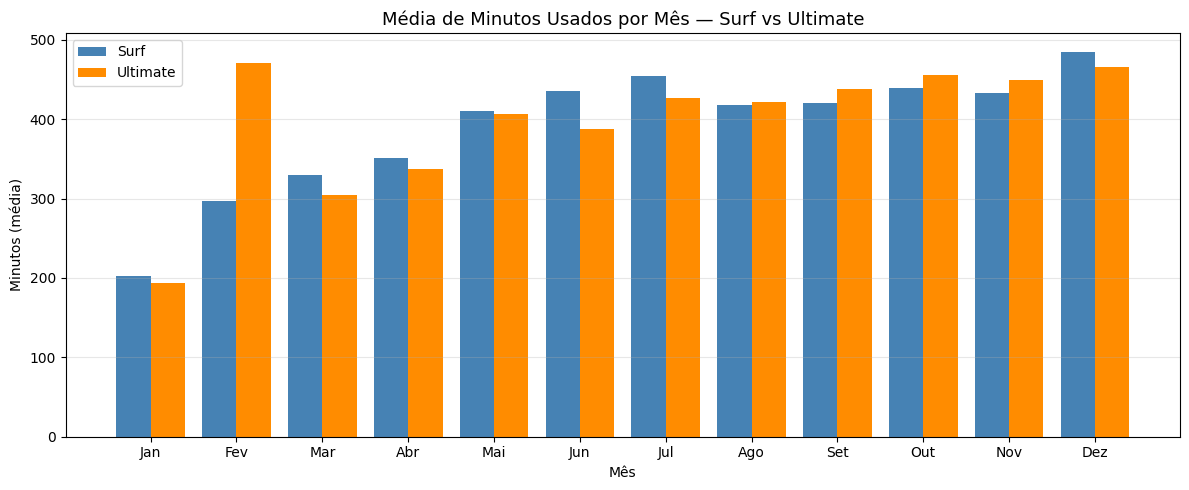

Estatísticas de minutos usados por plano:
            mean       var     std
plan                              
surf      436.52  52571.06  229.28
ultimate  434.68  56573.63  237.85


In [31]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.
# Duração média mensal por plano
calls_mean = df.groupby(['plan', 'month'])['minutes_used'].mean().reset_index()

# Separando os planos
surf_calls     = calls_mean[calls_mean['plan'] == 'surf']
ultimate_calls = calls_mean[calls_mean['plan'] == 'ultimate']

# Gráfico de barras lado a lado
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(1, 13)
width = 0.4

ax.bar(x - width/2, surf_calls['minutes_used'],     width, label='Surf',     color='steelblue')
ax.bar(x + width/2, ultimate_calls['minutes_used'], width, label='Ultimate', color='darkorange')

ax.set_title('Média de Minutos Usados por Mês — Surf vs Ultimate', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('Minutos (média)')
ax.set_xticks(x)
ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun',
                    'Jul','Ago','Set','Out','Nov','Dez'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas descritivas por plano
print("Estatísticas de minutos usados por plano:")
print(df.groupby('plan')['minutes_used'].agg(['mean', 'var', 'std']).round(2))


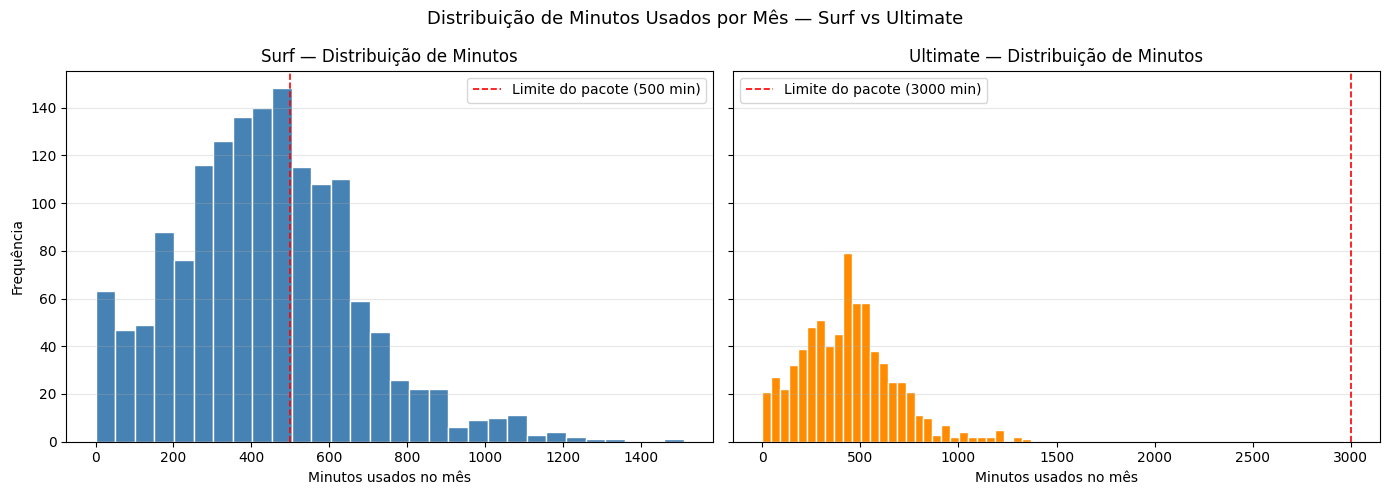

In [32]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

surf_minutes     = df[df['plan'] == 'surf']['minutes_used']
ultimate_minutes = df[df['plan'] == 'ultimate']['minutes_used']

axes[0].hist(surf_minutes, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(500, color='red', linestyle='--', linewidth=1.2, label='Limite do pacote (500 min)')
axes[0].set_title('Surf — Distribuição de Minutos')
axes[0].set_xlabel('Minutos usados no mês')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(ultimate_minutes, bins=30, color='darkorange', edgecolor='white')
axes[1].axvline(3000, color='red', linestyle='--', linewidth=1.2, label='Limite do pacote (3000 min)')
axes[1].set_title('Ultimate — Distribuição de Minutos')
axes[1].set_xlabel('Minutos usados no mês')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Distribuição de Minutos Usados por Mês — Surf vs Ultimate', fontsize=13)
plt.tight_layout()
plt.show()

In [33]:
# Calcule a média e a variância da duração mensal das chamadas
print("Média e variância de minutos usados por plano:\n")
print(df.groupby('plan')['minutes_used'].agg(['mean', 'var', 'std']).round(2))

print("\nMinutos usados — Surf:")
print(f"  Média:    {surf_minutes.mean():.2f}")
print(f"  Variância: {surf_minutes.var():.2f}")
print(f"  Desvio padrão: {surf_minutes.std():.2f}")

print("\nMinutos usados — Ultimate:")
print(f"  Média:    {ultimate_minutes.mean():.2f}")
print(f"  Variância: {ultimate_minutes.var():.2f}")
print(f"  Desvio padrão: {ultimate_minutes.std():.2f}")


Média e variância de minutos usados por plano:

            mean       var     std
plan                              
surf      436.52  52571.06  229.28
ultimate  434.68  56573.63  237.85

Minutos usados — Surf:
  Média:    436.52
  Variância: 52571.06
  Desvio padrão: 229.28

Minutos usados — Ultimate:
  Média:    434.68
  Variância: 56573.63
  Desvio padrão: 237.85


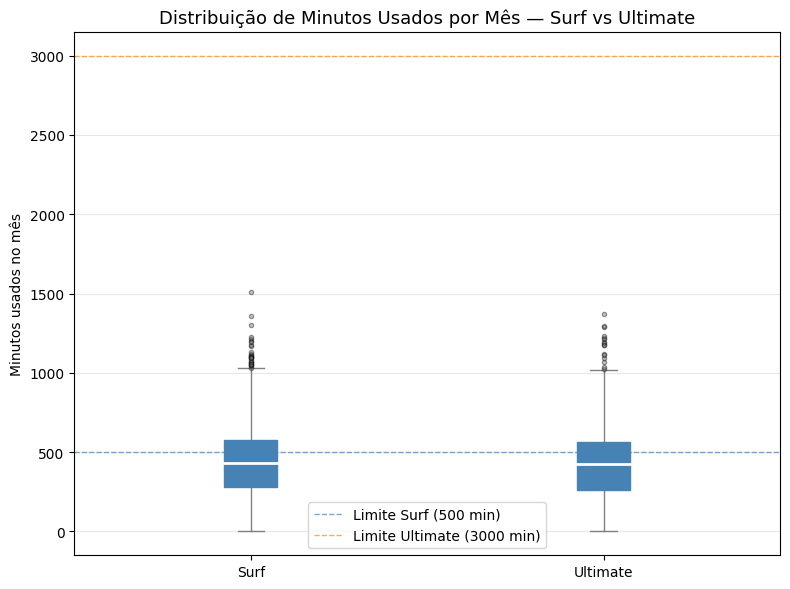

In [34]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    [surf_minutes, ultimate_minutes],
    labels=['Surf', 'Ultimate'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='steelblue'),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.4)
)

ax.axhline(500,  color='steelblue', linestyle='--', linewidth=1, alpha=0.7, label='Limite Surf (500 min)')
ax.axhline(3000, color='darkorange', linestyle='--', linewidth=1, alpha=0.7, label='Limite Ultimate (3000 min)')

ax.set_title('Distribuição de Minutos Usados por Mês — Surf vs Ultimate', fontsize=13)
ax.set_ylabel('Minutos usados no mês')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

- As médias são quase idênticas: 436 minutos por mês no Surf, 435 no Ultimate. Variância e desvio padrão também ficaram no mesmo patamar. Olhando só para os números, parece que os dois grupos se comportam igual — e de fato se comportam, no que diz respeito ao volume de uso.
- O histograma do Surf mostra a distribuição concentrada antes de 500 minutos, mas com uma cauda relevante se estendendo até 1.500. Essa cauda é excedente — cada minuto ali vale $0,03 para a Megaline. No Ultimate, a linha vermelha de 3.000 minutos está tão distante da distribuição real que praticamente não existe usuário chegando perto. Ninguém excede o pacote de minutos do Ultimate.
- O boxplot confirma isso visualmente: as caixas dos dois planos são quase sobrepostas, medianas em torno de 500 minutos. A diferença está nos outliers do Surf que pagam excedente, enquanto os outliers do Ultimate ainda ficam confortavelmente dentro do pacote.
Em resumo: os usuários ligam a mesma quantidade independente do plano. Mas os usuários do Surf que têm meses de uso mais intenso pagam por isso, enquanto os do Ultimate não. Isso vai aparecer com clareza na análise de receita.

### Mensagens

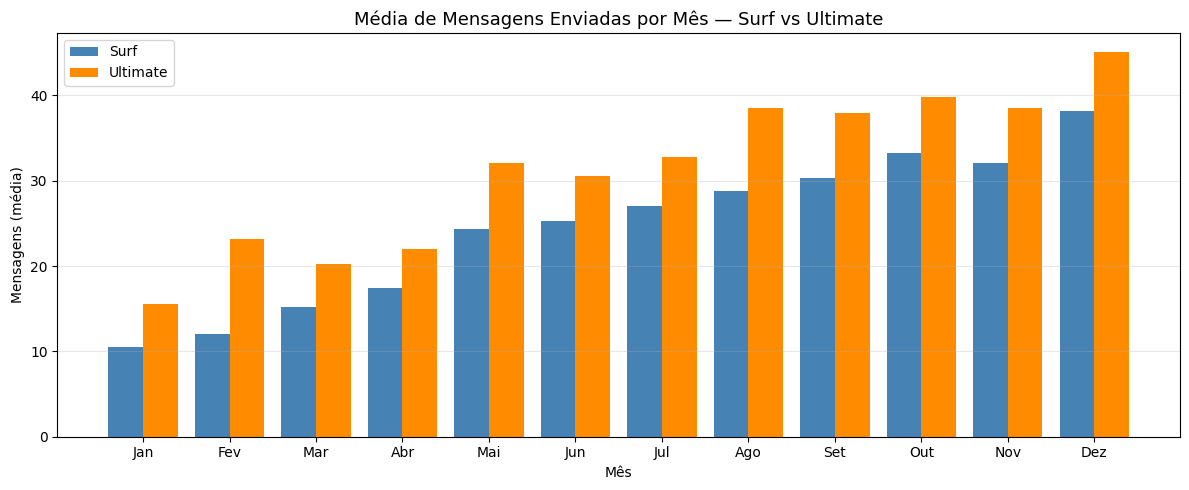

Estatísticas de mensagens enviadas por plano:

           mean      var    std
plan                           
surf      30.90  1131.95  33.64
ultimate  37.73  1210.14  34.79

Mensagens — Surf:
  Média:         30.90
  Variância:     1131.95
  Desvio padrão: 33.64

Mensagens — Ultimate:
  Média:         37.73
  Variância:     1210.14
  Desvio padrão: 34.79


In [35]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
# Média de mensagens por mês e por plano
messages_mean = df.groupby(['plan', 'month'])['messages_count'].mean().reset_index()

surf_msg     = messages_mean[messages_mean['plan'] == 'surf']
ultimate_msg = messages_mean[messages_mean['plan'] == 'ultimate']

# Gráfico de barras lado a lado
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(1, 13)
width = 0.4

ax.bar(x - width/2, surf_msg['messages_count'],     width, label='Surf',     color='steelblue')
ax.bar(x + width/2, ultimate_msg['messages_count'], width, label='Ultimate', color='darkorange')

ax.set_title('Média de Mensagens Enviadas por Mês — Surf vs Ultimate', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('Mensagens (média)')
ax.set_xticks(x)
ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun',
                    'Jul','Ago','Set','Out','Nov','Dez'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas descritivas por plano
surf_msgs     = df[df['plan'] == 'surf']['messages_count']
ultimate_msgs = df[df['plan'] == 'ultimate']['messages_count']

print("Estatísticas de mensagens enviadas por plano:\n")
print(df.groupby('plan')['messages_count'].agg(['mean', 'var', 'std']).round(2))

print("\nMensagens — Surf:")
print(f"  Média:         {surf_msgs.mean():.2f}")
print(f"  Variância:     {surf_msgs.var():.2f}")
print(f"  Desvio padrão: {surf_msgs.std():.2f}")

print("\nMensagens — Ultimate:")
print(f"  Média:         {ultimate_msgs.mean():.2f}")
print(f"  Variância:     {ultimate_msgs.var():.2f}")
print(f"  Desvio padrão: {ultimate_msgs.std():.2f}")


Comportamento dos usuários em mensagens:
Médias de 31 mensagens por mês no Surf e 38 no Ultimate. Desvio padrão em torno de 34 nos dois grupos. Os usuários se comportam de forma bastante parecida aqui também.
O que muda, de novo, é onde o limite cai.
O Surf inclui 50 mensagens por mês. Com média de 31 e desvio padrão de 34, uma parte dos usuários passa desse limite com facilidade. Quem manda 80 mensagens num mês pagou 30 extras a $0,03 cada — $0,90 a mais na conta. Parece pouco, mas somado ao excedente de dados e minutos, vai acumulando.
No Ultimate, o limite de 1.000 mensagens é tão alto que nenhum usuário chega perto. A média de 38 está a quilômetros do pacote. SMS simplesmente não é fonte de excedente nesse plano.
Uma coisa que chama atenção: os usuários do Ultimate mandam consistentemente mais mensagens do que os do Surf ao longo de todos os meses, como mostra o gráfico de barras. Não é uma diferença enorme, mas é consistente. Pode ser que o perfil de usuário que escolhe o Ultimate seja naturalmente mais comunicativo — ou pode ser que usuários do Surf evitem mandar mensagens justamente porque sabem que o limite é baixo. Não dá para confirmar com esses dados, mas é uma hipótese razoável.
De qualquer forma, mensagens não são o motor de receita de nenhum dos dois planos. O volume de uso é baixo demais para gerar excedente significativo.


### Internet

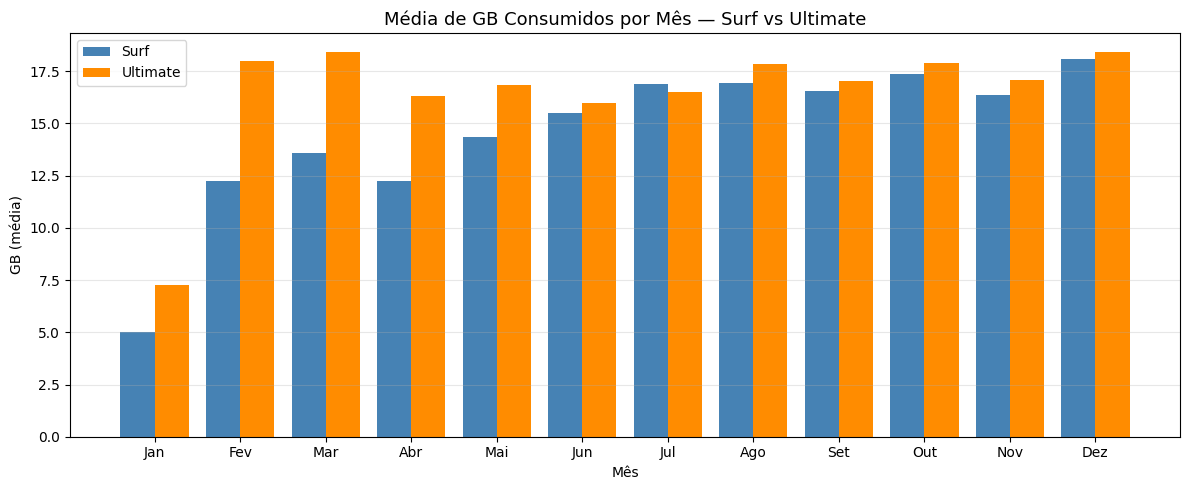

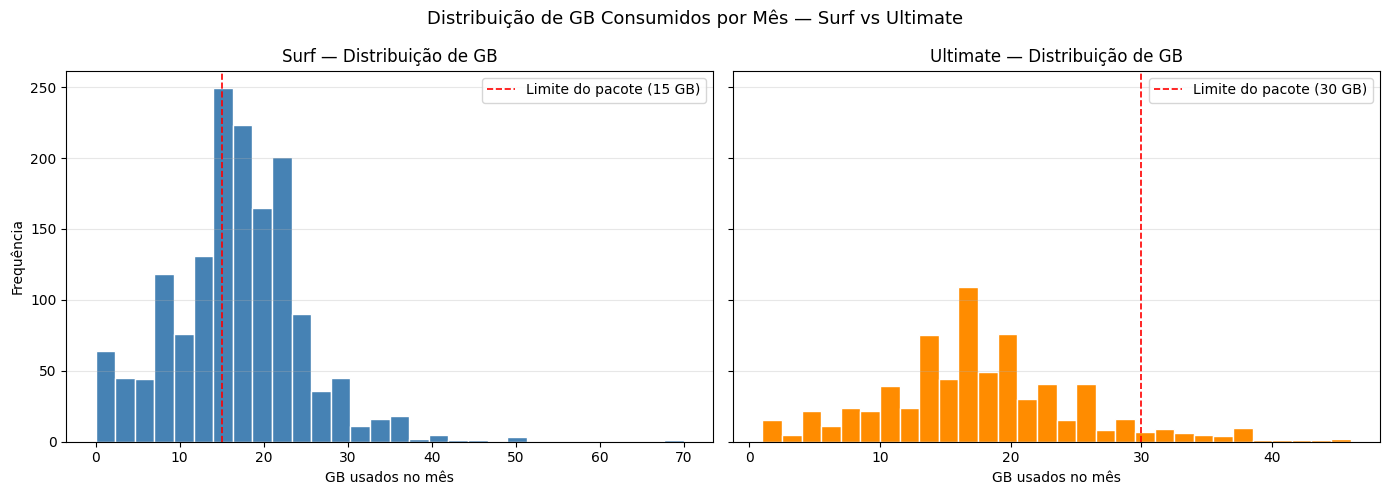

Estatísticas de GB consumidos por plano:

           mean    var   std
plan                        
surf      16.62  59.10  7.69
ultimate  17.37  57.46  7.58

GB — Surf:
  Média:         16.62
  Variância:     59.10
  Desvio padrão: 7.69

GB — Ultimate:
  Média:         17.37
  Variância:     57.46
  Desvio padrão: 7.58


In [36]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
# Média de GB por mês e por plano
internet_mean = df.groupby(['plan', 'month'])['gb_used'].mean().reset_index()

surf_inet     = internet_mean[internet_mean['plan'] == 'surf']
ultimate_inet = internet_mean[internet_mean['plan'] == 'ultimate']

# Gráfico de barras lado a lado
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(1, 13)
width = 0.4

ax.bar(x - width/2, surf_inet['gb_used'],     width, label='Surf',     color='steelblue')
ax.bar(x + width/2, ultimate_inet['gb_used'], width, label='Ultimate', color='darkorange')

ax.set_title('Média de GB Consumidos por Mês — Surf vs Ultimate', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('GB (média)')
ax.set_xticks(x)
ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun',
                    'Jul','Ago','Set','Out','Nov','Dez'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Histograma
surf_gb     = df[df['plan'] == 'surf']['gb_used']
ultimate_gb = df[df['plan'] == 'ultimate']['gb_used']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(surf_gb, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(15, color='red', linestyle='--', linewidth=1.2, label='Limite do pacote (15 GB)')
axes[0].set_title('Surf — Distribuição de GB')
axes[0].set_xlabel('GB usados no mês')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(ultimate_gb, bins=30, color='darkorange', edgecolor='white')
axes[1].axvline(30, color='red', linestyle='--', linewidth=1.2, label='Limite do pacote (30 GB)')
axes[1].set_title('Ultimate — Distribuição de GB')
axes[1].set_xlabel('GB usados no mês')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Distribuição de GB Consumidos por Mês — Surf vs Ultimate', fontsize=13)
plt.tight_layout()
plt.show()

# Estatísticas descritivas
print("Estatísticas de GB consumidos por plano:\n")
print(df.groupby('plan')['gb_used'].agg(['mean', 'var', 'std']).round(2))

print("\nGB — Surf:")
print(f"  Média:         {surf_gb.mean():.2f}")
print(f"  Variância:     {surf_gb.var():.2f}")
print(f"  Desvio padrão: {surf_gb.std():.2f}")

print("\nGB — Ultimate:")
print(f"  Média:         {ultimate_gb.mean():.2f}")
print(f"  Variância:     {ultimate_gb.var():.2f}")
print(f"  Desvio padrão: {ultimate_gb.std():.2f}")


As médias ficaram próximas — 16 GB no Surf e 17 GB no Ultimate — mas essa proximidade esconde uma diferença importante.
No Surf, o limite de 15 GB está bem no meio da distribuição. Uma parcela considerável dos usuários passa desse limite todo mês, e cada GB extra custa $10. É o excedente mais caro dos três serviços, e provavelmente o maior responsável pela receita variável do plano.
No Ultimate, o limite de 30 GB está confortavelmente à direita da distribuição. Olhando o histograma, são pouquíssimos os meses em que algum usuário chega perto — e menos ainda os que ultrapassam. Na prática, os usuários do Ultimate pagam $70 fixos e ficam por aí.
O desvio padrão é parecido nos dois planos (7.69 no Surf, 7.58 no Ultimate), o que indica variabilidade de consumo semelhante. O comportamento em si não é diferente — os usuários consomem quantidades parecidas de dados independente do plano escolhido. O que muda é que no Surf esse consumo frequentemente ultrapassa o pacote, enquanto no Ultimate o pacote é amplo o suficiente para absorver praticamente todos os casos.
Diferente das chamadas, onde o excedente aparecia mas não era absurdo, em dados o impacto financeiro é mais direto. Um usuário do Surf que consome 20 GB num mês pagou $70 — o mesmo que a mensalidade inteira do Ultimate.


## Receita

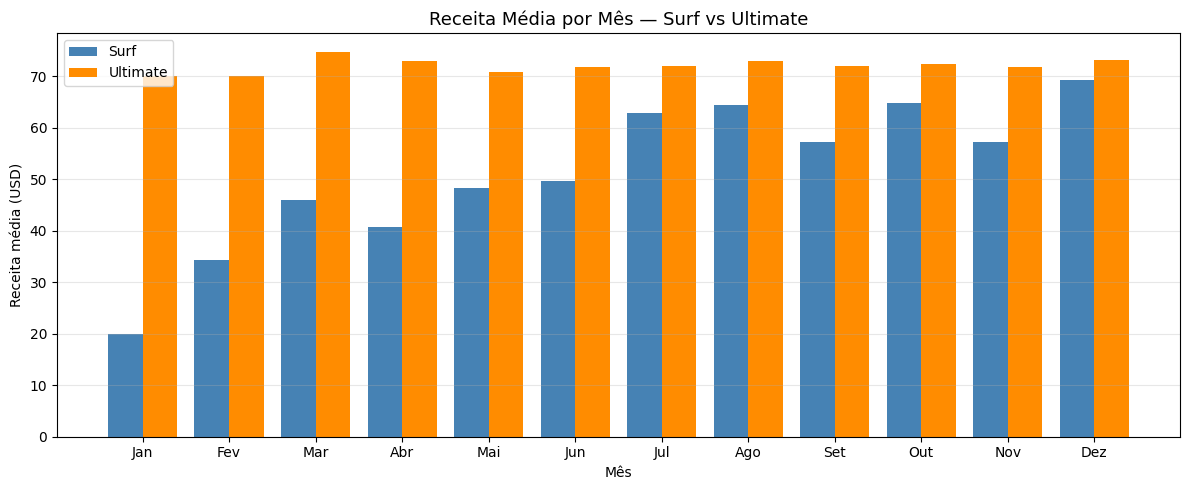

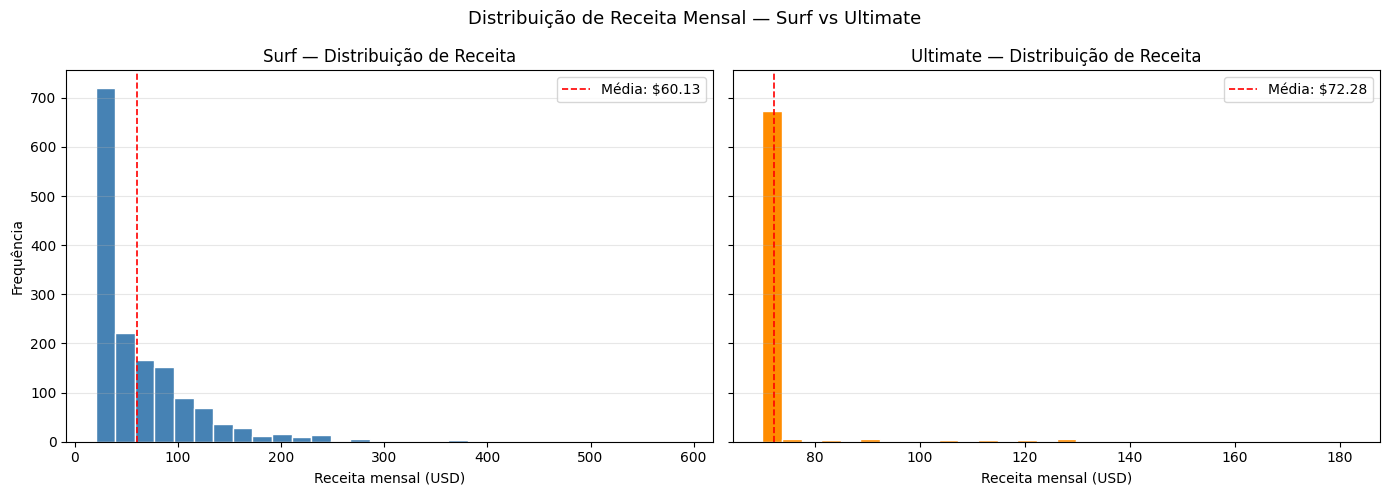

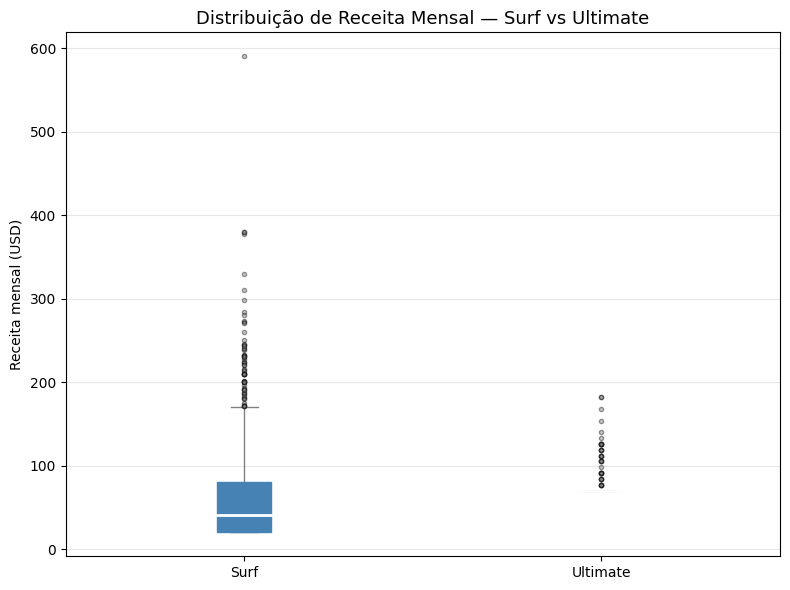

Estatísticas de receita por plano:

           mean      var    std
plan                           
surf      60.13  2865.82  53.53
ultimate  72.28   128.87  11.35

Receita — Surf:
  Média:         $60.13
  Variância:      2865.82
  Desvio padrão: $53.53

Receita — Ultimate:
  Média:         $72.28
  Variância:      128.87
  Desvio padrão: $11.35


In [37]:
# Média de receita por mês e por plano
revenue_mean = df.groupby(['plan', 'month'])['revenue'].mean().reset_index()

surf_rev     = revenue_mean[revenue_mean['plan'] == 'surf']
ultimate_rev = revenue_mean[revenue_mean['plan'] == 'ultimate']

# Gráfico de barras — receita média mensal por plano
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(1, 13)
width = 0.4

ax.bar(x - width/2, surf_rev['revenue'],     width, label='Surf',     color='steelblue')
ax.bar(x + width/2, ultimate_rev['revenue'], width, label='Ultimate', color='darkorange')

ax.set_title('Receita Média por Mês — Surf vs Ultimate', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('Receita média (USD)')
ax.set_xticks(x)
ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun',
                    'Jul','Ago','Set','Out','Nov','Dez'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Histograma da distribuição de receita
surf_revenue     = df[df['plan'] == 'surf']['revenue']
ultimate_revenue = df[df['plan'] == 'ultimate']['revenue']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(surf_revenue, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(surf_revenue.mean(), color='red', linestyle='--',
                linewidth=1.2, label=f'Média: ${surf_revenue.mean():.2f}')
axes[0].set_title('Surf — Distribuição de Receita')
axes[0].set_xlabel('Receita mensal (USD)')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(ultimate_revenue, bins=30, color='darkorange', edgecolor='white')
axes[1].axvline(ultimate_revenue.mean(), color='red', linestyle='--',
                linewidth=1.2, label=f'Média: ${ultimate_revenue.mean():.2f}')
axes[1].set_title('Ultimate — Distribuição de Receita')
axes[1].set_xlabel('Receita mensal (USD)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Distribuição de Receita Mensal — Surf vs Ultimate', fontsize=13)
plt.tight_layout()
plt.show()

# Boxplot
fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    [surf_revenue, ultimate_revenue],
    labels=['Surf', 'Ultimate'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='steelblue'),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.4)
)

ax.set_title('Distribuição de Receita Mensal — Surf vs Ultimate', fontsize=13)
ax.set_ylabel('Receita mensal (USD)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas descritivas
print("Estatísticas de receita por plano:\n")
print(df.groupby('plan')['revenue'].agg(['mean', 'var', 'std']).round(2))

print("\nReceita — Surf:")
print(f"  Média:         ${surf_revenue.mean():.2f}")
print(f"  Variância:      {surf_revenue.var():.2f}")
print(f"  Desvio padrão: ${surf_revenue.std():.2f}")

print("\nReceita — Ultimate:")
print(f"  Média:         ${ultimate_revenue.mean():.2f}")
print(f"  Variância:      {ultimate_revenue.var():.2f}")
print(f"  Desvio padrão: ${ultimate_revenue.std():.2f}")

O Ultimate gera mais receita por usuário: $72,28 de média mensal contra $60,13 do Surf. Mas a diferença mais interessante não está na média — está na variância.
O Surf tem desvio padrão de $53,53. O Ultimate, $11,35. Isso explica tudo que os gráficos mostram.
O histograma do Surf é o retrato de um plano imprevisível: a maioria dos registros está empilhada perto de $20 — usuários que ficaram dentro do pacote e pagaram só a mensalidade — mas tem uma cauda longa se estendendo até $600. São os usuários que estouraram o limite de dados em algum mês e pagaram caro por isso. A média de $60 está bem longe de onde a distribuição se concentra de fato, o que significa que ela é puxada para cima por esses casos extremos.
O histograma do Ultimate é o oposto: uma barra vertical em $70 e praticamente nada fora disso. Quase nenhum usuário excede os limites do plano, então a receita é quase inteiramente composta pela mensalidade fixa. Previsível, estável, sem surpresa.
O boxplot resume bem: a caixa do Surf é pequena mas os outliers se espalham até $600. A caixa do Ultimate mal existe — tudo concentrado em $70.
Para o departamento comercial, isso tem implicação direta. O Ultimate é mais rentável em média e completamente previsível. O Surf gera menos em média, mas tem usuários que pagam muito mais do que o esperado. A receita do Surf depende de quão intensamente os clientes usam o serviço; a do Ultimate, não.

## Teste hipóteses estatísticas

In [38]:
# Teste as hipóteses
surf_revenue     = df[df['plan'] == 'surf']['revenue']
ultimate_revenue = df[df['plan'] == 'ultimate']['revenue']

# Teste t de Welch — equal_var=False por causa da diferença de variâncias
t_stat, p_value = stats.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)

print(f"Estatística t: {t_stat:.4f}")
print(f"P-valor:       {p_value:.4f}")
print()

if p_value < 0.05:
    print("Resultado: rejeitamos H0.")
    print("A diferença entre as receitas médias é estatisticamente significativa.")
else:
    print("Resultado: não rejeitamos H0.")
    print("Não há evidência suficiente para afirmar que as receitas médias são diferentes.")


Estatística t: -8.5173
P-valor:       0.0000

Resultado: rejeitamos H0.
A diferença entre as receitas médias é estatisticamente significativa.


Hipóteses:
H0: A receita média mensal dos usuários do Surf é igual à dos usuários do Ultimate.
H1: A receita média mensal dos usuários do Surf é diferente da dos usuários do Ultimate.
O teste é bilateral — não há razão para assumir de antemão qual plano gera mais. A pergunta é só se existe diferença, não em qual direção.
Teste escolhido: t-test de Welch (duas amostras independentes)
O t-test compara as médias de dois grupos independentes e verifica se a diferença observada é estatisticamente significativa ou pode ser explicada por variação aleatória. O Welch é a variante correta aqui porque as variâncias dos dois grupos são muito diferentes — $2.865 no Surf contra $128 no Ultimate. O t-test de Student assume variâncias iguais, o que claramente não é o caso. O Welch não faz essa suposição e é mais robusto nessa situação.
Alfa: 0,05
Com alfa de 5%, estamos dispostos a aceitar uma probabilidade de 5% de rejeitar a hipótese nula quando ela é verdadeira. É o limiar padrão para análises desse tipo e faz sentido aqui — não estamos tomando uma decisão médica ou de segurança, mas uma decisão de alocação de orçamento de publicidade. Um erro de 5% é tolerável nesse contexto.
Se o p-valor calculado ficar abaixo de 0,05, rejeitamos H0 e concluímos que a diferença entre as médias é estatisticamente significativa. Se ficar acima, não há evidência suficiente para afirmar que os planos geram receitas diferentes.

Interpretação do resultado:
P-valor praticamente zero. A diferença entre as receitas médias dos dois planos não é ruído estatístico — é real.
Rejeitamos H0 com folga. A receita média do Ultimate ($72,28) é significativamente maior que a do Surf ($60,13), e esse resultado dificilmente seria observado se os dois planos gerassem a mesma receita por usuário na população.
A estatística t de -8,52 reforça isso: um valor tão distante de zero indica que a diferença entre as médias é grande em relação à variação interna de cada grupo. Mesmo com o Surf tendo desvio padrão muito maior que o Ultimate — o que dificulta a detecção de diferenças —, o teste ainda assim encontrou evidência forte o suficiente para rejeitar H0.
Em termos práticos: o Ultimate gera mais receita por usuário por mês, e essa conclusão tem respaldo estatístico sólido.

In [39]:
# Teste as hipóteses
# Separando os grupos com base na flag is_nynj criada na etapa 1.7.2
nynj_revenue  = df[df['is_nynj'] == True]['revenue']
other_revenue = df[df['is_nynj'] == False]['revenue']

print(f"Usuários NY-NJ:       {nynj_revenue.count()} registros mensais")
print(f"Usuários demais regiões: {other_revenue.count()} registros mensais")
print(f"\nReceita média NY-NJ:          ${nynj_revenue.mean():.2f}")
print(f"Receita média demais regiões: ${other_revenue.mean():.2f}")
print()

# Teste t de Welch
t_stat, p_value = stats.ttest_ind(nynj_revenue, other_revenue, equal_var=False)

print(f"Estatística t: {t_stat:.4f}")
print(f"P-valor:       {p_value:.4f}")
print()

if p_value < 0.05:
    print("Resultado: rejeitamos H0.")
    print("A diferença entre as receitas médias é estatisticamente significativa.")
else:
    print("Resultado: não rejeitamos H0.")
    print("Não há evidência suficiente para afirmar que as receitas médias são diferentes.")


Usuários NY-NJ:       371 registros mensais
Usuários demais regiões: 1887 registros mensais

Receita média NY-NJ:          $58.87
Receita média demais regiões: $64.96

Estatística t: -2.4887
P-valor:       0.0131

Resultado: rejeitamos H0.
A diferença entre as receitas médias é estatisticamente significativa.


Hipóteses:
H0: A receita média mensal dos usuários da região NY-NJ é igual à dos usuários das demais regiões.
H1: A receita média mensal dos usuários da região NY-NJ é diferente da dos usuários das demais regiões.
Teste bilateral pelo mesmo motivo do anterior — não há hipótese prévia sobre qual grupo gera mais receita, só se existe diferença.
Teste escolhido: t-test de Welch (duas amostras independentes)
A lógica é a mesma: dois grupos independentes, médias a comparar, e não há garantia de que as variâncias sejam iguais entre usuários de NY-NJ e do restante do país. O Welch continua sendo a escolha mais segura.
Alfa: 0,05
Mesmo critério da hipótese anterior. Vale registrar um ponto adicional aqui: NY-NJ tem 80 usuários contra 420 do restante. Amostras desbalanceadas não são problema para o t-test de Welch, mas significa que a estimativa para NY-NJ tem mais incerteza — um grupo menor produz uma média menos estável. Se o resultado ficar próximo do limiar de 0,05, isso merece atenção na interpretação.
Se p-valor < 0,05, rejeitamos H0 e concluímos que a região faz diferença na receita gerada. Se ficar acima, não há evidência de que usuários de NY-NJ se comportam de forma diferente do restante em termos de receita.

Interpretação do resultado:
P-valor de 0,013. Rejeitamos H0 — a diferença é estatisticamente significativa.
O resultado, porém, vai na direção contrária ao que se poderia esperar. Usuários de NY-NJ geram em média $58,87 por mês, enquanto o restante do país gera $64,96. A região com maior concentração de clientes na base é também a que gera menos receita por usuário.
A estatística t de -2,49 indica que a diferença é real, mas bem menos expressiva do que a encontrada na hipótese anterior entre os planos. Lá o t foi -8,52. Aqui chegou a -2,49 — ainda além do limiar, mas com menos folga.
Vale um olhar mais cuidadoso antes de tirar conclusões sobre o que causa essa diferença. Uma possibilidade é que a distribuição de planos em NY-NJ seja diferente do restante — se a região tiver proporcionalmente mais usuários Surf, a receita média naturalmente cai. Outra é que o comportamento de consumo em si seja diferente. Com os dados disponíveis não dá para separar os dois efeitos, mas é o próximo passo natural caso essa análise precise ir mais fundo.
Para o departamento comercial, o dado concreto é este: NY-NJ, apesar de ser de longe a maior praça da base, não é a mais lucrativa por usuário. Isso pode influenciar tanto a alocação de verba publicitária quanto a estratégia de qual plano empurrar nessa região.